<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto de Regresión Logística**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto campaña de Marketing Bancario  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Campaña de Marketing Bancario**

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los <u>clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo</u>. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema **crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **bank-marketing-campaign-data.csvv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/bank-marketing-campaign-data.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [2]:
# IMPORTACIONES LIBRERIAS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [3]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv', sep=';')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
2163,48,blue-collar,married,basic.9y,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
33399,32,blue-collar,married,basic.9y,no,yes,no,cellular,may,tue,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.291,5099.1,no
38180,28,unemployed,single,basic.4y,no,yes,yes,cellular,oct,fri,...,1,999,0,nonexistent,-3.4,92.431,-26.9,0.752,5017.5,no
24470,37,management,divorced,unknown,no,no,yes,cellular,nov,mon,...,1,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,no
21059,34,admin.,married,university.degree,no,yes,no,telephone,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
22396,55,retired,married,professional.course,no,yes,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
31887,50,admin.,married,basic.9y,no,no,no,cellular,may,thu,...,6,999,0,nonexistent,-1.8,92.893,-46.2,1.327,5099.1,no
29408,40,services,single,high.school,no,no,no,cellular,apr,mon,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,yes
24102,36,admin.,married,high.school,no,yes,no,telephone,nov,wed,...,1,999,1,failure,-0.1,93.200,-42.0,4.286,5195.8,yes
16950,25,blue-collar,single,basic.9y,no,no,yes,cellular,jul,thu,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

A continuación se detallan las variables incluidas en el dataset:

### 📊 Diccionario de Datos

| Variable            | Descripción                                                                 | Tipo        |
|--------------------|-----------------------------------------------------------------------------|------------|
| age                | Edad del cliente                                                           | Numérico   |
| job                | Tipo de trabajo                                                            | Categórico |
| marital            | Estado civil                                                               | Categórico |
| education          | Nivel de educación                                                         | Categórico |
| default            | ¿Tiene crédito actualmente?                                                | Categórico |
| housing            | ¿Tiene un préstamo de vivienda?                                            | Categórico |
| loan               | ¿Tiene un préstamo personal?                                               | Categórico |
| contact            | Tipo de comunicación de contacto                                           | Categórico |
| month              | Último mes en el que se le ha contactado                                   | Categórico |
| day_of_week        | Último día en el que se le ha contactado                                   | Categórico |
| duration           | Duración del contacto previo en segundos                                   | Numérico   |
| campaign           | Número de contactos realizados durante esta campaña al cliente             | Numérico   |
| pdays              | Número de días desde la última campaña hasta el contacto                   | Numérico   |
| previous           | Número de contactos en la campaña anterior                                 | Numérico   |
| poutcome           | Resultado de la campaña de marketing anterior                              | Categórico |
| emp.var.rate       | Tasa de variación del empleo (indicador trimestral)                        | Numérico   |
| cons.price.idx     | Índice de precios al consumidor (indicador mensual)                        | Numérico   |
| cons.conf.idx      | Índice de confianza del consumidor (indicador mensual)                     | Numérico   |
| euribor3m          | Tasa EURIBOR a 3 meses (indicador diario)                                  | Numérico   |
| nr.employed        | Número de empleados (indicador trimestral)                                 | Numérico   |
| y                  | **TARGET**: ¿El cliente contrata un depósito a largo plazo?                | Categórico |

### 🌍 Variables Macroeconómicas (Contexto Económico)

| Variable        | Descripción                                                                 | Tipo      | Intuición clave |
|----------------|-----------------------------------------------------------------------------|----------|----------------|
| emp.var.rate   | Tasa de variación del empleo (indicador trimestral)                         | Numérico | Indica si el empleo está creciendo o disminuyendo. Más empleo → mayor estabilidad económica → mayor capacidad de ahorro. |
| cons.price.idx | Índice de precios al consumidor (IPC, indicador mensual)                    | Numérico | Mide el nivel de precios (inflación). Afecta al poder adquisitivo y a las decisiones de consumo y ahorro. |
| cons.conf.idx  | Índice de confianza del consumidor (indicador mensual)                      | Numérico | Refleja el optimismo de los consumidores. Mayor confianza → mayor disposición a gastar o invertir. |
| euribor3m      | Tipo de interés Euribor a 3 meses (indicador diario)                         | Numérico | Representa el coste del dinero. Euribor alto → depósitos más atractivos → mayor probabilidad de contratación. |
| nr.employed    | Número total de empleados (indicador trimestral)                            | Numérico | Indica la salud del mercado laboral. Más empleados → economía más fuerte → mayor capacidad de ahorro. |



Este diccionario de datos será clave para interpretar correctamente las relaciones entre variables durante el análisis exploratorio (EDA).

</div>

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**

El dataset muestra un conjunto de variables asociadas a clientes del banco, que se pueden clasificar de la siguiente manera:

- Personal: `age`, `job`, `marital`, `education`
- Crediticia: `default`, `housing`, `loan`
- Datos de la llamada: `contact`, `month`, `day_of_week`, `duration`
- Datos de campañas: `campaign`, `pdays`, `previous`, `poutcome`
- Datos macroeconómicos: `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`

No se observa a simple vista una columna que identifique unívocamente cada registro. Además, la variable `campaign` indica el número de contactos realizados durante la campaña actual a un cliente en el momento del registro. Esto sugiere que cada fila representa un evento de contacto, y que un mismo cliente podría aparecer en múltiples registros con valores crecientes en esta variable.

No obstante, la ausencia de un identificador único de cliente impide confirmar esta relación de forma directa. Asimismo, no existe una variable que identifique explícitamente las distintas campañas, aunque variables como `previous`, `pdays` y `poutcome` indican la existencia de interacciones previas en campañas anteriores.

💭 Hipótesis:
Cada fila podría representar un contacto (llamada) realizado a un cliente en un momento determinado. Esta hipótesis deberá ser validada posteriormente mediante el análisis de duplicados y la comprensión de las variables relacionadas con las campañas.


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Realiza un EDA completo**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.1: Inspección inicial del dataset**

</div>

In [34]:
# Obtener las dimensiones
df.shape

(41188, 21)

In [35]:
# Obtener información sobre tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [36]:
# Valores nulos
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**

El dataset contiene un total de 41.188 observaciones y 21 variables (incluyendo la target).

No se detectan valores nulos en ninguna de las variables, por lo que no es necesario realizar ningún tratamiento adicional en esta fase.

Se observa la presencia de variables tanto numéricas como categóricas, lo que implicará la necesidad de aplicar técnicas de codificación para las variables categóricas en fases posteriores del análisis.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.2: Inspección valores unicos y duplicados**

</div>

In [37]:
# Veamos cuantos valores unicos y no unicos (repetidos) hay en cada variable

df_uniques = df.nunique()
df_repeated = len(df) - df_uniques

resumen = pd.DataFrame({
    'valores_unicos': df_uniques,
    'valores_repetidos': df_repeated
})

resumen

,valores_unicos,valores_repetidos
age,78,41110
job,12,41176
marital,4,41184
education,8,41180
default,3,41185
housing,3,41185
loan,3,41185
contact,2,41186
month,10,41178
day_of_week,5,41183


In [38]:
# Se seleccionan las posibles variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Creamos un resumen más legible de las variables categóricas
cat_summary = pd.DataFrame({
    "variable": cat_vars,
    "n_valores_unicos": [df[col].nunique() for col in cat_vars],
    "valores": [", ".join(map(str, df[col].dropna().unique())) for col in cat_vars]
})
pd.set_option('display.max_colwidth', None)
cat_summary

,variable,n_valores_unicos,valores
0,job,12,"housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, unknown, entrepreneur, student"
1,marital,4,"married, single, divorced, unknown"
2,education,8,"basic.4y, high.school, basic.6y, basic.9y, professional.course, unknown, university.degree, illiterate"
3,default,3,"no, unknown, yes"
4,housing,3,"no, yes, unknown"
5,loan,3,"no, yes, unknown"
6,contact,2,"telephone, cellular"
7,month,10,"may, jun, jul, aug, oct, nov, dec, mar, apr, sep"
8,day_of_week,5,"mon, tue, wed, thu, fri"
9,poutcome,3,"nonexistent, failure, success"


In [39]:
# Veamos si existe duplicado de filas (filas completamente identicas en todas su variables en el dataset)
df.duplicated().sum()

np.int64(12)

In [40]:
# Veamos si hay columnas duplicadas entre sí
df.T.duplicated()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp.var.rate      False
cons.price.idx    False
cons.conf.idx     False
euribor3m         False
nr.employed       False
y                 False
dtype: bool

In [41]:
# Mostrar todas las filas duplicadas (original y copia) para su inspección
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**

Las 10 variables categóricas (excluyendo la target) presentan un número reducido de valores únicos, siendo la variable `job` la de mayor cardinalidad con 12 valores. Esto facilita su tratamiento mediante técnicas de codificación en fases posteriores.

Por otro lado, variables como `job`, `marital`, `education`, `default`, `housing` y `loan` incluyen la categoría `unknown`, si el procentajes de valores `unknown` es muy alto quizas deban ser tratados adecuadamente más adelante.

Se identifican 12 filas completamente duplicadas en el dataset. Dado que presentan exactamente los mismos valores en todas sus variables, es probable que se trate de registros redundantes. **No obstante, su tratamiento se abordará en la fase de ingenieria de caracteristicas para mantener la coherencia del proceso de análisis.**

Ademas, se ha comprobado si existe duplicado en las columnas y el resultado es negativo, con lo qu ecada carateristica representa informacion diferente.

Todo lo observado hasta ahora no permite confirmar ni descartar la hipótesis de que cada fila representa un contacto (llamada), por lo que será necesario profundizar en el análisis para validar esta suposición a continuación:

</div>

In [42]:
# Definimos las variables que representan el perfil del cliente
cols = ['age', 'job', 'marital', 'education']

# Para cada perfil, contamos cuántos valores distintos de 'campaign' existen
perfil_campaign = df.groupby(cols)['campaign'].nunique()

# Filtramos aquellos perfiles que aparecen con más de un valor de 'campaign'
perfiles_repetidos = perfil_campaign[perfil_campaign > 1].reset_index()

# Seleccionamos uno de esos perfiles para inspeccionarlo en detalle
perfil = perfiles_repetidos.iloc[0]

# Mostramos todas las filas que corresponden a ese perfil
df[
    (df['age'] == perfil['age']) &
    (df['job'] == perfil['job']) &
    (df['marital'] == perfil['marital']) &
    (df['education'] == perfil['education'])
][cols + ['campaign']].sort_values('campaign')

,age,job,marital,education,campaign
37539,17,student,single,basic.9y,2
37579,17,student,single,basic.9y,2
37558,17,student,single,basic.9y,3


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación (Validación de hipótesis)**:

Se ha analizado la variable `campaign` en combinación con variables que definen el perfil del cliente (edad, trabajo, estado civil, etc.), observándose que existen múltiples registros con características similares y valores crecientes en `campaign`. 

Esto sugiere que un mismo cliente podría haber sido contactado varias veces dentro de la misma campaña.

No obstante, debido a la ausencia de un identificador único de cliente, no es posible confirmarlo con total certeza, aunque la evidencia observada es consistente con esta interpretación

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.3: Análisis estadístico descriptivo**

</div>

In [43]:
# Se calculan estadísticas descriptivo para las variables numericas comprender su distribución, rango de valores y posibles valores outliers
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**:

- **age** presenta una distribución aproximadamente simétrica, ya que la media (40.02) y la mediana (38) están relativamente próximas. No se observan indicios claros de valores atípicos relevantes.

- **duration** muestra una distribución claramente asimétrica a la derecha. La desviación estándar (259.27) es similar e incluso superior a la media (258.28), y el valor máximo (4918) está muy alejado de la mediana (180), lo que indica la presencia de valores extremos.

- **campaign** indica el número de contactos realizados en la campaña actual. Presenta un comportamiento similar al de `duration`, con una distribución sesgada a la derecha. Aunque la mayoría de los valores se concentran en valores bajos (mediana = 2), existen valores máximos elevados (56) que incrementan significativamente la desviación estándar, lo que sugiere la presencia de outliers.

- **pdays** requiere una interpretación más detallada. Esta variable representa el número de días transcurridos desde el último contacto en una campaña anterior. El valor 999 no corresponde a un número real de días, sino que indica que el cliente no fue contactado previamente. Esto explica que tanto el percentil 25, mediana y percentil 75 sean 999, mostrando que la mayoría de los clientes no tuvieron contacto previo.

- **previous** indica el número de contactos realizados en campañas anteriores. Se observa que la gran mayoría de los valores son 0 (mediana = 0, media = 0.17), lo que sugiere que la mayoría de los clientes no habían sido contactados anteriormente. Los valores más altos como el 7 puede que represente casos poco frecuentes.

- Las variables **emp.var.rate**, **cons.price.idx**, **cons.conf.idx**, **euribor3m** y **nr.employed** representan el contexto económico en el momento del contacto. Aunque en esta fase no se profundiza en su análisis, podrían resultar relevantes en etapas posteriores del modelado.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable (variables numericas)**

</div>

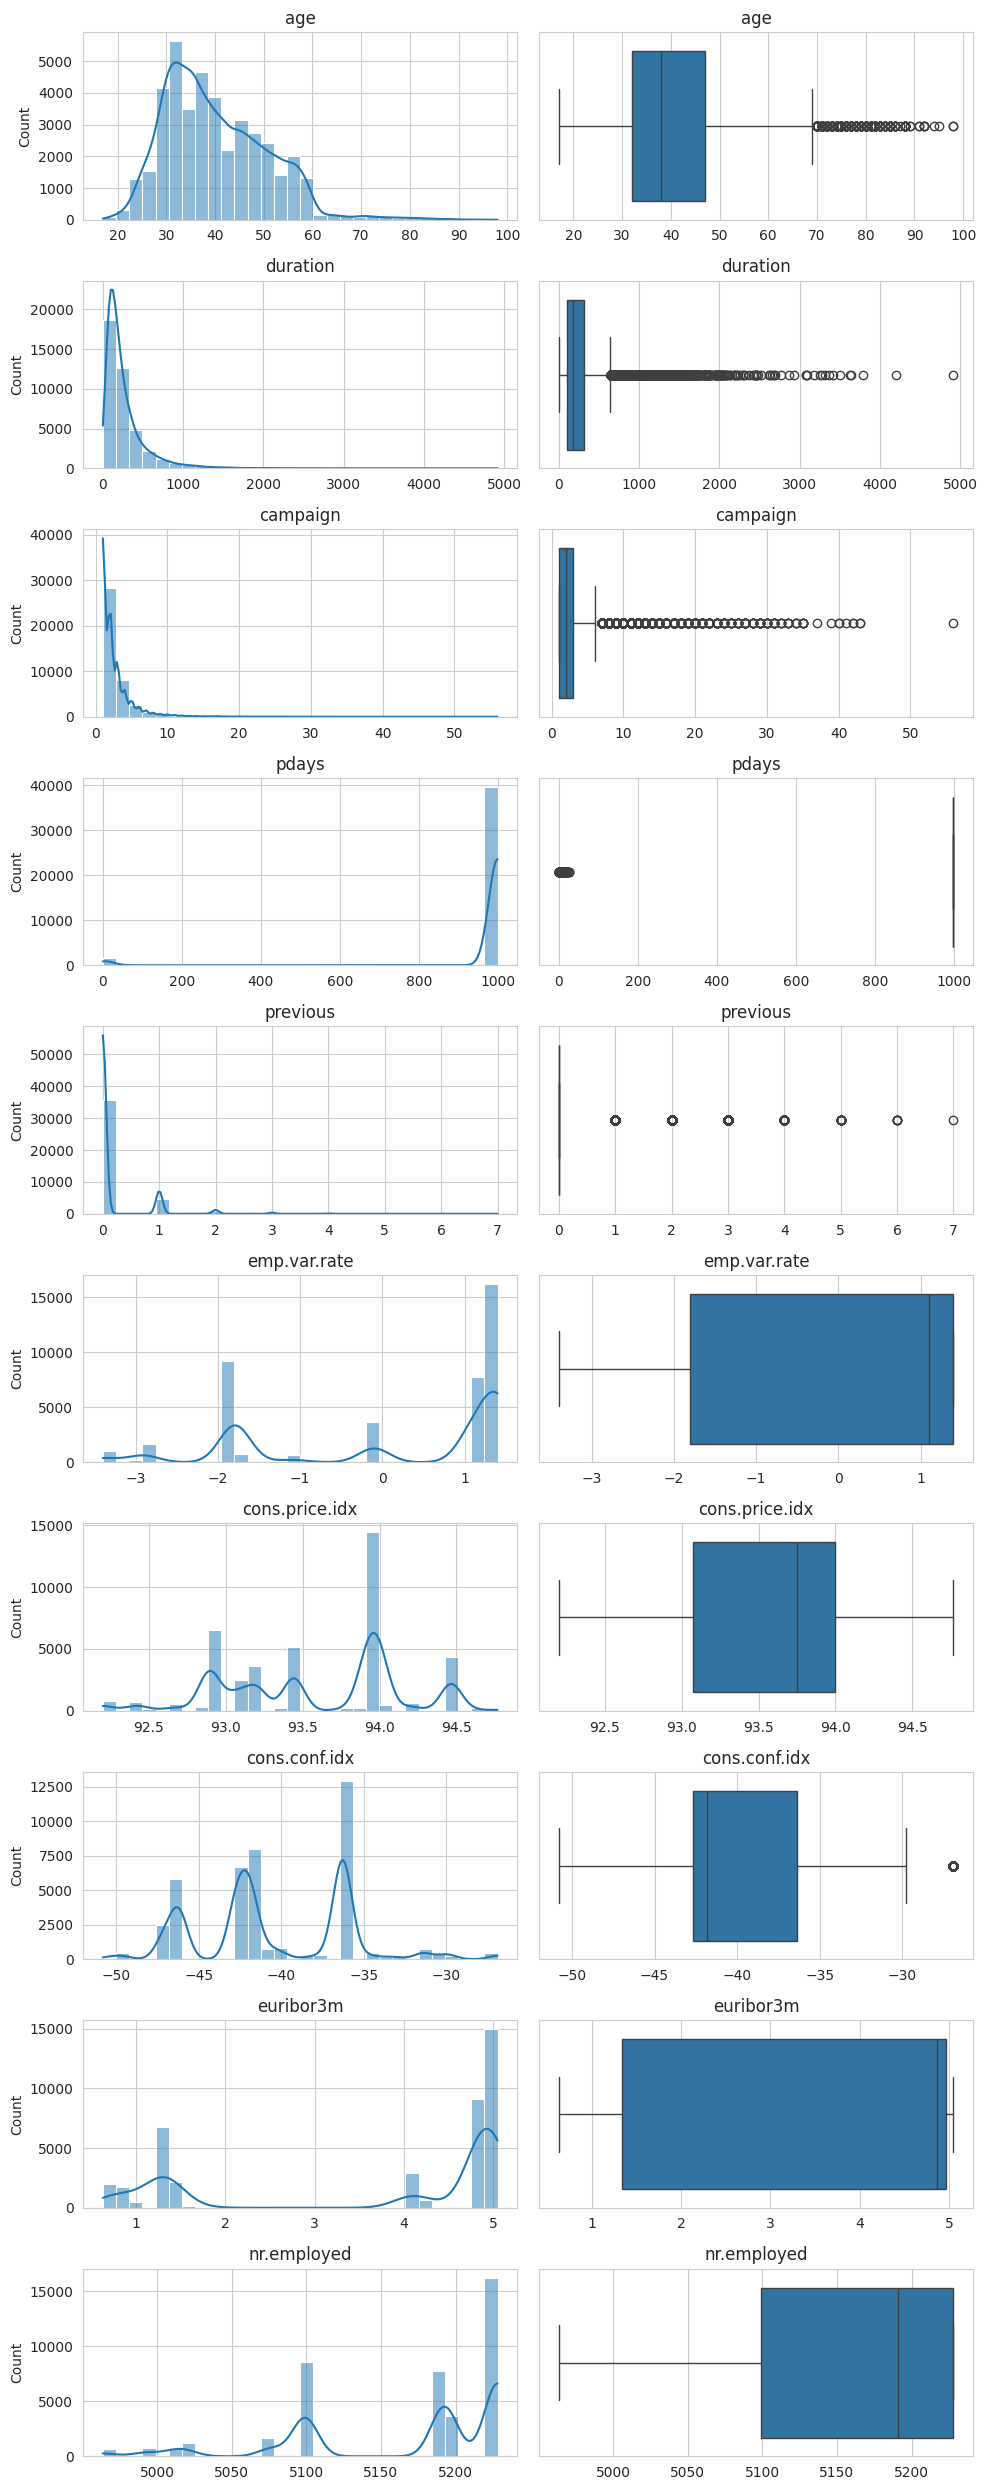

In [ ]:
# Seleccionamos variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Estilo limpio
sns.set_style("whitegrid")

# Ajustamos tamaño (más compacto que el tuyo)
fig, axes = plt.subplots(len(num_vars), 2, figsize=(10, 2.5*len(num_vars)))

for i, col in enumerate(num_vars):

    # Histograma
    sns.histplot(df[col], bins=30, ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f'{col}')
    axes[i, 0].set_xlabel('')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación (refinada tras graficos)**:

- **age** Aunque inicialmente la variable `age` parecía presentar una distribución aproximadamente simétrica al comparar media y mediana, el análisis gráfico revela una ligera asimetría hacia la derecha.

    Se observa una mayor concentración de valores entre los 30 y 50 años, con una cola que se extiende hacia edades más avanzadas. El boxplot confirma la presencia de valores atípicos en edades altas.

- **campaign y previous** Aunque las variables `campaign` y `previous` representan el número de contactos realizados, muestran distribuciones muy diferentes.

    La variable `previous` presenta una fuerte concentración en el valor 0, lo que indica que la mayoría de los clientes no habían sido contactados en campañas anteriores, comportándose como una variable prácticamente discreta.

    Por el contrario, `campaign` muestra una distribución más dispersa y asimétrica, con presencia de valores elevados, lo que sugiere que durante la campaña actual algunos clientes han sido contactados múltiples veces.

    Esto refleja diferencias en el comportamiento histórico frente al actual de las campañas de marketing.

- **duration** La variable `duration` presenta una distribución fuertemente asimétrica a la derecha, con una alta concentración de valores bajos y una cola larga que incluye valores extremos. Esto indica que la mayoría de las llamadas son de corta duración, aunque existen algunos casos con duraciones significativamente elevadas.

- **pdays** la variable `pdays` muestra una distribución altamente concentrada en el valor 999, lo que sugiere que la mayoría de los clientes no habían sido contactados previamente. Este comportamiento indica que la variable contiene un valor codificado que representa la ausencia de contacto previo, lo que deberá tenerse en cuenta en fases posteriores del análisis.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.4: Análisis univariable (variables categóricas)**

</div>

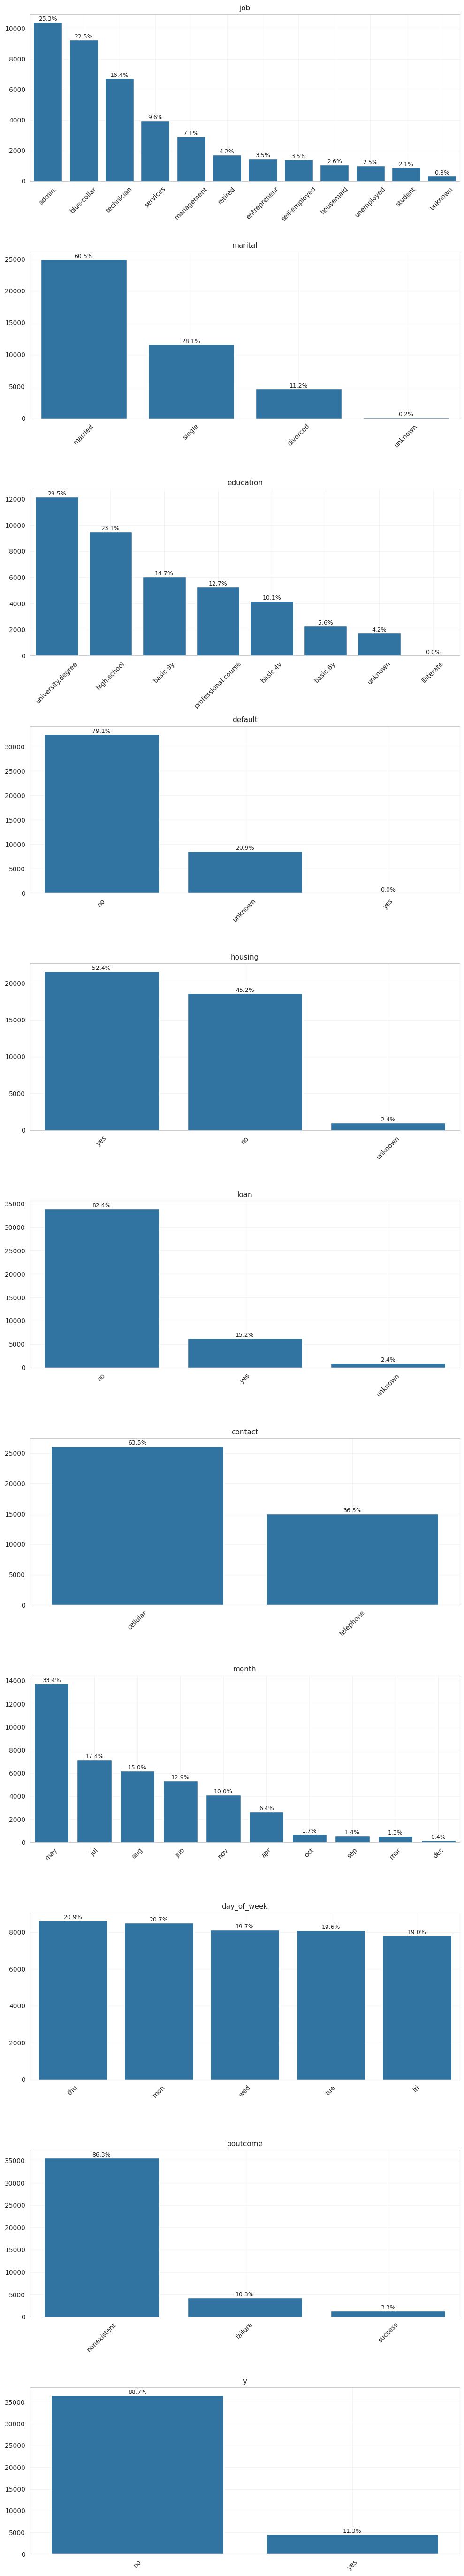

In [45]:
# Seleccionamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Estilo limpio
sns.set_style("whitegrid")

# Tamaño dinámico (más alto para que se vea mejor)
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(10, 5 * len(cat_vars)))

# Si solo hay una variable, axes no es lista → lo convertimos
if len(cat_vars) == 1:
    axes = [axes]

for i, col in enumerate(cat_vars):

    # Countplot ordenado por frecuencia
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)

    # Añadir porcentajes encima de cada barra
    total = len(df)
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].text(
            p.get_x() + p.get_width() / 2,
            height,
            f'{height/total:.1%}',
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Estética
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**:

Las variables categóricas presentan una distribución desigual entre sus categorías. En el caso de la variable `job`, se observa que las categorías `admin.` (~25%) y `blue-collar` (~22%) concentran la mayor proporción de registros, seguidas por `technician` (~16%).

El resto de categorías presentan una frecuencia significativamente menor, muchas de ellas por debajo del 5%, lo que indica la existencia de categorías minoritarias. Además, la categoría `unknown` representa un porcentaje muy reducido (~1%), lo que sugiere que su impacto en el análisis podría ser limitado.

La variable objetivo (y) se incluye dentro del análisis univariable de variables categóricas, observandose un fuerte desbalance entre clases, con una clara predominancia de la categoría "no" frente a "yes", lo cual podría afectar la capacidad del modelo para predecir correctamente la clase minoritaria.

Para facilitar la interpretación, se ha optado por representar las distribuciones en términos porcentuales en lugar de frecuencias absolutas.

</div>


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.5: Analisis bivariante (categoricas vs target)**

</div>

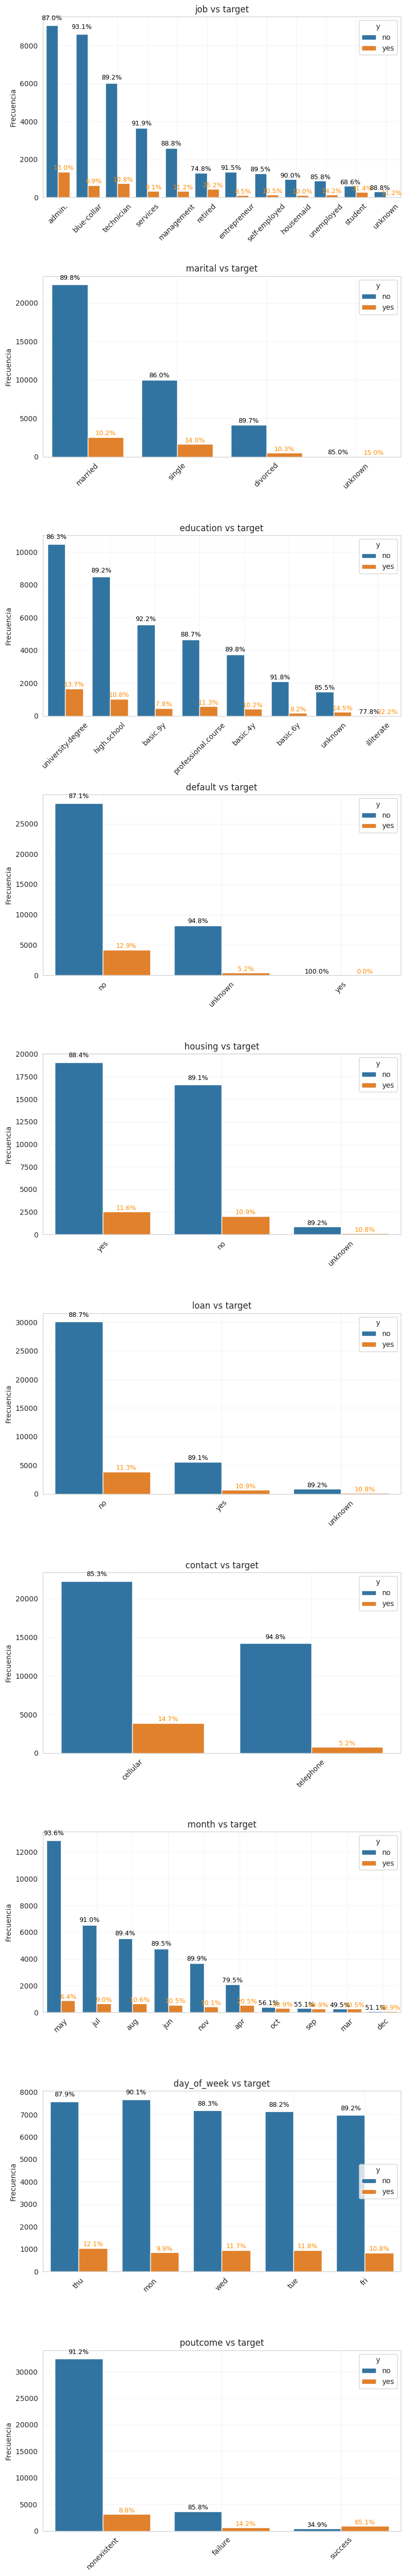

In [46]:
# ============================================
# Gráficos categóricos vs target (y)
# con porcentaje de 'yes' y 'no'
# ============================================

# Seleccionamos variables categóricas
cat_vars = df.select_dtypes(include=['object', 'string']).columns

# Quitamos la target
cat_vars = [col for col in cat_vars if col != 'y']

# Estilo visual
sns.set_style("whitegrid")

# Creamos figura (más alto que ancho, como te gusta)
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(8, 5 * len(cat_vars)))

# Si solo hay una variable
if len(cat_vars) == 1:
    axes = [axes]

# Loop por cada variable categórica
for i, col in enumerate(cat_vars):

    order = df[col].value_counts().index

    ax = sns.countplot(
        data=df,
        x=col,
        hue='y',
        order=order,
        ax=axes[i]
    )

    # Tabla de proporciones
    prop = pd.crosstab(df[col], df['y'], normalize='index').reindex(order)

    # Añadir porcentajes
    for j, category in enumerate(order):

        count_no = df[(df[col] == category) & (df['y'] == 'no')].shape[0]
        count_yes = df[(df[col] == category) & (df['y'] == 'yes')].shape[0]

        pct_no = prop.loc[category, 'no'] if 'no' in prop.columns else 0
        pct_yes = prop.loc[category, 'yes'] if 'yes' in prop.columns else 0

        # Texto NO (barra azul)
        ax.text(
            j - 0.2,
            count_no + max(count_no * 0.02, 5),
            f'{pct_no:.1%}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

        # Texto YES (barra naranja)
        ax.text(
            j + 0.2,
            count_yes + max(count_yes * 0.02, 5),
            f'{pct_yes:.1%}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='darkorange'
        )

    # Estética
    ax.set_title(f'{col} vs target', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.2)
    ax.legend(title='y')

plt.tight_layout()
plt.show()

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación (Análisis bivariante: variables categóricas vs target):**

El análisis bivariante de las variables categóricas frente a la variable objetivo (y) permite identificar patrones de comportamiento en la contratación del depósito:

- Variables temporales como `month` y `day_of_week` no muestran un impacto significativo en la decisión de contratación, observándose distribuciones bastante homogéneas. Aunque el mes de mayo presenta un mayor volumen de contrataciones, esto parece estar influenciado por un mayor número de contactos y no necesariamente por una mayor propensión.

- En cuanto al canal de contacto (`contact`), se observa un mayor número de contrataciones en clientes contactados vía móvil. No obstante, esta diferencia podría estar condicionada por la mayor frecuencia de uso de este canal frente al teléfono fijo, más que por una mayor efectividad del mismo.

- Respecto a variables financieras, los clientes que no presentan créditos (`default = no`, `loan = no`) muestran una mayor proporción de contratación, lo que sugiere que una menor carga financiera podría estar asociada a una mayor capacidad o disposición para invertir en depósitos a largo plazo.

- En el caso de `housing`, se aprecia una ligera mayor propensión a la contratación en clientes con préstamo hipotecario, aunque la diferencia no es lo suficientemente marcada como para considerarla determinante.

- La variable `poutcome` resulta especialmente relevante: los clientes que tuvieron un resultado previo exitoso (`success`) presentan una proporción significativamente mayor de contratación, lo que indica una fuerte relación entre experiencias positivas previas y la probabilidad de conversión.

En conclusión, las variables `default`, `housing`, `loan` y `poutcome` muestran una mayor influencia sobre la variable objetivo que las variables `month`, `day_of_week` y `contact`. Por su parte, variables como `job`, `marital` y `education` no presentan diferencias suficientemente marcadas en la proporción de contratación entre sus categorías, lo que sugiere un impacto limitado en la variable objetivo en esta fase del análisis.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.6: Analisis bivariante (numéricas vs target)**

</div>

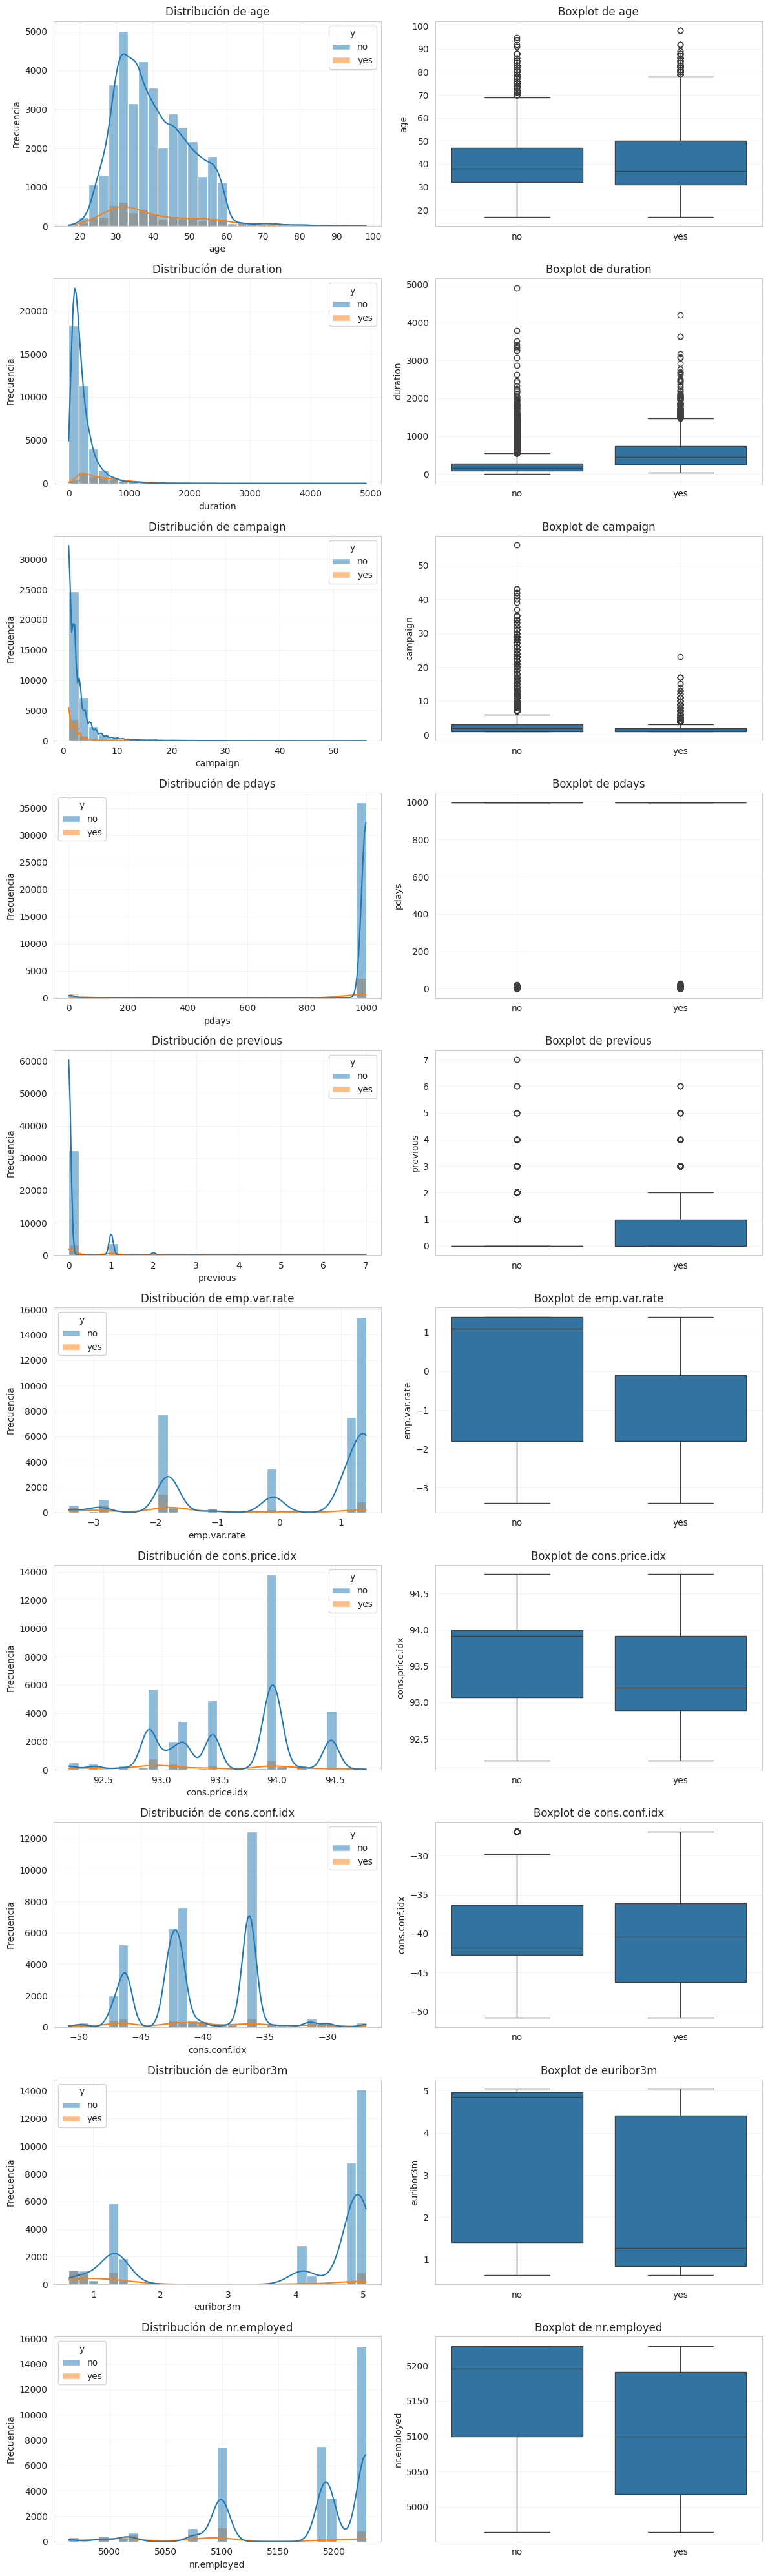


📊 Media de variables numéricas por grupo (y):



y,no,yes
age,39.911185,40.913147
duration,220.844807,553.191164
campaign,2.633085,2.051724
pdays,984.113878,792.035560
previous,0.132374,0.492672
emp.var.rate,0.248875,-1.233448
cons.price.idx,93.603757,93.354386
cons.conf.idx,-40.593097,-39.789784
euribor3m,3.811491,2.123135
nr.employed,5176.166600,5095.115991


In [47]:
# ============================================
# Análisis numérico vs target (visual + tabla)
# ============================================

# Seleccionamos variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns
num_vars = [col for col in num_vars if col != 'y']

sns.set_style("whitegrid")

# ============================================
# 1. GRÁFICOS (histograma + boxplot)
# ============================================

fig, axes = plt.subplots(len(num_vars), 2, figsize=(12, 4 * len(num_vars)))

# Si solo hay una variable
if len(num_vars) == 1:
    axes = [axes]

for i, col in enumerate(num_vars):

    # HISTOGRAMA
    sns.histplot(data=df, x=col, hue='y', bins=30, kde=True, ax=axes[i][0])
    axes[i][0].set_title(f'Distribución de {col}')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frecuencia')
    axes[i][0].grid(True, alpha=0.2)

    # BOXPLOT
    sns.boxplot(data=df, x='y', y=col, ax=axes[i][1])
    axes[i][1].set_title(f'Boxplot de {col}')
    axes[i][1].set_xlabel('')
    axes[i][1].set_ylabel(col)
    axes[i][1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================
# 2. TABLA (media por grupo)
# ============================================

tabla_medias = df.groupby('y')[num_vars].mean().T

print("\n📊 Media de variables numéricas por grupo (y):\n")
display(tabla_medias)

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación (Análisis bivariante: variables numéricas vs target):**

El análisis de las variables numéricas en relación con la variable objetivo (`y`) permite identificar qué variables presentan mayor capacidad discriminativa entre clientes que contratan y no contratan el depósito.

La variable **duration** destaca claramente como la más influyente, observándose una diferencia significativa en la distribución entre ambos grupos: los clientes que contratan (`yes`) presentan duraciones de llamada considerablemente mayores, con una mediana claramente desplazada respecto a los que no contratan, lo que sugiere una fuerte relación entre la duración del contacto y la probabilidad de contratación.

En cuanto a **campaign**, se observa que los clientes que no contratan tienden a presentar un mayor número de contactos dentro de la campaña, mientras que aquellos que contratan suelen concentrarse en valores más bajos, lo que podría indicar una menor necesidad de insistencia en clientes con mayor predisposición.

La variable **previous** muestra que los clientes que contratan presentan, en general, un mayor número de contactos en campañas anteriores, lo que sugiere que la recurrencia en el contacto puede estar asociada a una mayor probabilidad de conversión.

Respecto a **pdays**, se observa una fuerte concentración en el valor 999 para ambos grupos, lo que indica que la mayoría de los clientes no habían sido contactados previamente. Esta variable requiere un tratamiento específico, ya que dicho valor parece representar una categoría implícita más que un valor numérico real.

En relación con **age**, no se aprecian diferencias suficientemente marcadas entre los grupos como para considerarla una variable determinante en la contratación.

Por último, las variables económicas (**emp.var.rate**, **cons.price.idx**, **cons.conf.idx**, **euribor3m**, **nr.employed**) muestran ligeras diferencias entre los grupos, especialmente en **euribor3m** y **nr.employed**, donde los clientes que contratan tienden a concentrarse en valores más bajos, lo que podría reflejar una mayor propensión a contratar depósitos en determinados contextos económicos.

En conjunto, las variables **duration**, **campaign**, **previous** y, en menor medida, **euribor3m** y **nr.employed**, parecen aportar mayor información para explicar la variable objetivo, mientras que variables como **age** presentan un impacto más limitado en esta fase del análisis.

</div>

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión final**

Tras el análisis exploratorio se puede concluir lo siguiente:

- Las variables que mas destacan como influyentes con la variable objetivo (y) son: `poutcome`, `duration`, `previous`, `campaign`, así como las variables financieras `default`, `housing` y `loan`. Por el contrario, variables como `job`, `marital`, `education`, `month`, `day_of_week` y `contact` muestran un impacto más limitado en la contratación.

- Las variables `default`, `housing` y `loan` parecen recoger información relacionada con la existencia de crédito o deuda activa del cliente. Dado que `housing` y `loan` representan tipos específicos de préstamo, mientras que `default` se define en la documentación como una variable más general (“¿Tiene crédito actualmente?”), podría existir cierto solapamiento entre ellas. No obstante, se pospondra a la fase de ingeniería de características el analisis detallado para determinar el grado real de redundancia entre las mismas. 

- La variable `contact` no parece aportar valor explicativo relevante sobre la variable objetivo, ya que las diferencias observadas podrían estar influenciadas por factores externos. Por ello, se considera candidata a eliminación en la fase de ingeniería de características.

- Se detectan 12 registros completamente duplicados en el dataset que podrían ser candidatos a eliminar en la siguiente fase de ingeniería de características.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Construye un modelo de regresión logística**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.1: Ingeniería de características**

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Acción sobre los 12 registros duplicados:**

Durante el EDA se detectarón 12 registros completamente duplicados en el dataset. Dado que representan una proporción mínima sobre el total de observaciones y no se dispone de un identificador único que permita confirmar si corresponden a registros redundantes o a contactos independientes con características coincidentes, no se procederá a su eliminación.

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Acción la variable `contact`:**

La variable `contact` indica el canal utilizado para contactar al cliente (teléfono fijo o móvil). Durante el EDA no se observa una relación clara y directa con la variable objetivo, ya que las diferencias en la proporción de contratación podrían estar influenciadas por factores externos, como el mayor uso actual del teléfono móvil frente al fijo, y no necesariamente por una mayor efectividad del canal en sí.

Por ello, se considera que esta variable **no aporta información relevante para el modelo** y se procede a elimanrla.

</div>

In [48]:
# Se elimina la variable ´contact´
fd = df.drop(columns=['contact'])

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Acción sobre variables `default`, `housing` y `loan`:**

Se ha analizado la posible relación entre las variables `default`, `housing` y `loan` con el objetivo de identificar si existe redundancia entre ellas.

Los resultados muestran que `default` no actúa como una variable general que agrupe a `housing` y `loan`, ya que existen numerosos casos en los que los clientes presentan préstamos activos (`housing` o `loan` en "yes") mientras que `default` permanece en "no".

Esto indica que `default` representa una dimensión distinta, posiblemente relacionada con el historial de impago o riesgo financiero, y no simplemente con la existencia de crédito.

Por tanto, no se considera redundante y se decide **mantener las tres variables** para su uso en el modelo.

</div>

In [49]:
df.groupby(['default', 'housing', 'loan']).size().reset_index(name='count')

,default,housing,loan,count
0,no,no,no,12606
1,no,no,yes,2008
2,no,unknown,unknown,763
3,no,yes,no,14243
4,no,yes,yes,2968
5,unknown,no,no,3457
6,unknown,no,yes,549
7,unknown,unknown,unknown,227
8,unknown,yes,no,3641
9,unknown,yes,yes,723


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.2: Separar X y y**

</div>

In [50]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df.drop(columns='y')
y = df['y']

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.3: Train / Test split**

</div>

In [51]:
# Dividimos los datos en entrenamiento y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.4: Codificación de variables categóricas (One-Hot Encoding)**

</div>

In [53]:
# Seleccionamos automáticamente las variables categóricas
cat_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns

# Aplicamos One-Hot Encoding:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)

# Aplicamos exactamente la misma transformación al conjunto de test
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos columnas entre train y test(puede haber categorías que aparezcan en uno y no en otro)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.5: Entrenamiento del modelo (Regresión Logística)**

</div>

In [56]:
# Inicializamos el modelo con configuración por defecto
model = LogisticRegression(max_iter=1000)

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación**

Durante el entrenamiento del modelo de regresión logística se ha incrementado el parámetro `max_iter` con el objetivo de permitir al algoritmo disponer de más iteraciones para alcanzar la convergencia.

No obstante, aun aumentando este valor, el modelo sigue mostrando un aviso de convergencia, lo que indica que no ha sido capaz de encontrar completamente el óptimo en el número de iteraciones establecido.

Este comportamiento puede estar relacionado con la diferencia de escala entre variables numéricas y la complejidad introducida tras la codificación de variables categóricas.

Dado que en esta fase se busca construir un modelo base, se continuará con la configuración actual, reservando técnicas como el escalado de variables para la fase de optimización.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3.6: Metricas del modelo base**

</div>

In [59]:
# Generamos las predicciones del modelo (clase final: 'yes' o 'no')
y_pred = model.predict(X_test)

# Probabilidad de pertenecer a la clase positiva ('yes')
# Se utilizará en fases posteriores para métricas más avanzadas
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.93      0.98      0.95      7310
         yes       0.70      0.42      0.53       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.91      8238



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusion final entrenamiento del modelo:**

El modelo base muestra un rendimiento significativamente mejor en la clase mayoritaria ("no") que en la clase positiva ("yes").

Mientras que las métricas para la clase "no" son elevadas, en la clase "yes" se observa un recall bajo (0.42), lo que indica que el modelo no es capaz de identificar correctamente una gran parte de los clientes que realmente contratan el depósito.

Este comportamiento está influenciado por el desbalance de la variable objetivo, llevando al modelo a favorecer la predicción de la clase mayoritaria.

Dado el contexto del problema, donde es relevante identificar correctamente a los clientes potenciales, será necesario mejorar la capacidad del modelo para detectar la clase "yes" en la fase de optimización.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Optimiza el modelo anterior**

</div>

<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Estrategia de optimización:**

Dado que el modelo presenta dificultades para converger y una baja capacidad para detectar la clase positiva ("yes"), se plantea una estrategia de optimización en dos fases.

En primer lugar, se aplicará el escalado de variables numéricas para mejorar la estabilidad del modelo y facilitar la convergencia del algoritmo.

Posteriormente, si el rendimiento sobre la clase positiva sigue siendo limitado, se abordará el desbalance de la variable objetivo mediante técnicas de balanceo, con el objetivo de mejorar la capacidad del modelo para identificar correctamente los clientes que contratan el depósito.


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4.1: Escalar**

Se utiliza StandardScaler, porque centra los datos en media 0 y desviación estándar 1 lo cual es especialmente adecuado para modelos lineales como la regresión logística, ayudando a mejorar la convergencia del algoritmo y evitando que variables con mayor escala dominen el modelo.

</div>

In [62]:
# Aplicamos StandardScaler a las variables numéricas
scaler = StandardScaler()

# Ajustamos SOLO con train y transformamos ambos (evitamos data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo con los datos de entrenamiento escalados
model.fit(X_train_scaled, y_train)

# Generamos las predicciones del modelo (clase final: 'yes' o 'no')
y_pred_scaled = model.predict(X_test_scaled)

# Probabilidad de pertenecer a la clase positiva ('yes')
# Se utilizará en fases posteriores para métricas más avanzadas
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_scaled))



              precision    recall  f1-score   support

          no       0.93      0.98      0.95      7310
         yes       0.71      0.44      0.54       928

    accuracy                           0.92      8238
   macro avg       0.82      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238



<div style="background-color: #fff3cd; border-left: 6px solid #ffecb5; padding: 15px; border-radius: 5px">

### 💡 **Observación:**

El modelo ha mejorado pero no en gran medida 
- Precision: 0.70 → 0.71 ✔️ (sube un poco)
- Recall: 0.42 → 0.44 ✔️ (sube un poco)
- F1-score: 0.53 → 0.54 ✔️ (sube un poco)

Basicamente el modelo:

- Detecta muy bien los "no" (recall 0.98)
- Pero sigue fallando muchos "yes" (recall 0.44)

Traducción negocio: Se te están escapando muchos clientes que sí contratarían


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4.1: Balancear**

Se aborda el desbalance de la variable objetivo utilizando el parámetro `class_weight='balanced'` en la regresión logística.

Esta técnica ajusta automáticamente el peso de cada clase durante el entrenamiento, penalizando más los errores cometidos sobre la clase minoritaria ("yes"), sin necesidad de modificar el dataset original.

A diferencia de técnicas como el oversampling, este enfoque permite mejorar la capacidad del modelo para detectar la clase positiva de forma sencilla y estable, siendo una primera aproximación adecuada antes de aplicar métodos más complejos.

El objetivo es incrementar el recall de la clase "yes", reduciendo el número de clientes que realmente contratarían el depósito pero que el modelo no identifica.

</div>

In [63]:
# Inicializamos el modelo aplicando balanceo de clases
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

# Entrenamos el modelo con los datos escalados
model_balanced.fit(X_train_scaled, y_train)

# Generamos predicciones (clase final)
y_pred_bal = model_balanced.predict(X_test_scaled)

# Probabilidades de la clase positiva ('yes')
y_prob_bal = model_balanced.predict_proba(X_test_scaled)[:, 1]

# Evaluamos el modelo
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

          no       0.99      0.86      0.92      7310
         yes       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusion optimización del modelo:**

Tras aplicar el balanceo de clases mediante `class_weight='balanced'`, se observa una mejora significativa en la capacidad del modelo para identificar la clase positiva ("yes"), incrementando notablemente el recall (de 0.44 a 0.91).

Este resultado indica que el modelo logra detectar la mayoría de los clientes que contratarían el depósito, aunque a costa de una reducción en la precisión, lo que implica un aumento en los falsos positivos.

Dado el contexto del problema, donde es preferible identificar potenciales clientes aunque se cometan algunos errores, este comportamiento se considera adecuado, priorizando la reducción de falsos negativos frente a falsos positivos.

</div>